In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

In [3]:
import numpy as np
import tensorflow as tf
np.random.seed(180) 
tf.random.set_seed(180) 

In [4]:
people = fetch_lfw_people( min_faces_per_person=20, resize=0.7 )
print(people.data.shape)
print(people.target.shape)
image_shape = people.images[0].shape 

(3023, 5655)
(3023,)


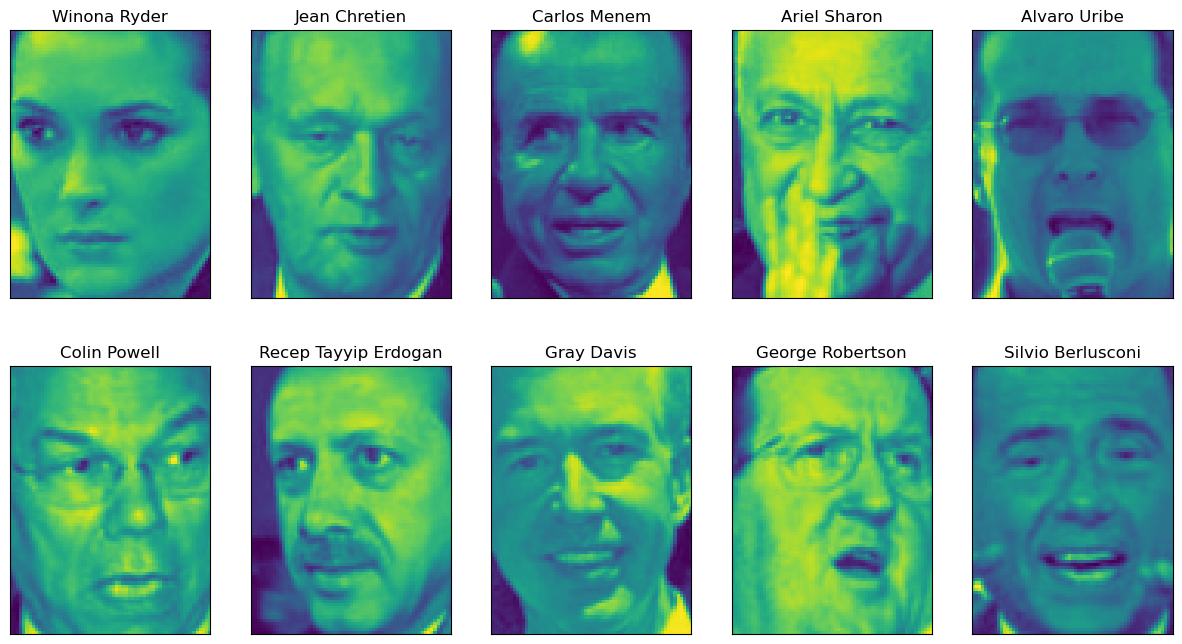

In [5]:
fix, axes = plt.subplots( 2, 5, figsize=(15,8), subplot_kw={'xticks':(), 'yticks':()} )
for target, image, ax in zip( people.target,  people.images,axes.ravel()): 
    ax.imshow(image)
    ax.set_title( people.target_names[target] )
plt.show() 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(     people.data,     people.target,     test_size=0.2,     random_state=20 )  
y_train = y_train.astype(int) 
y_test = y_test.astype(int) 
batch_size = len(X_train) 
print(     X_train.shape,     y_train.shape,     y_test.shape ) 
print(     "people.images.shape: {}".format(         people.images.shape     ) )  
print(     "Number of classes: {}".format(         len(people.target_names)     ) ) 

(2418, 5655) (2418,) (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62


In [7]:
count = np.bincount(people.target) 
for i, (count, name) in enumerate(zip(count, people.target_names)):
    print("{0:25} {1:3}".format(name,count),end=" "     ) 
    if (i+1)%3 == 0:        
        print() 

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 
Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 
Carlos Menem               21 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 
Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 
Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 
Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 
Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 

In [8]:
mask = np.zeros(people.target.shape,dtype=np.bool_ )  
for target in np.unique(people.target):    
    mask[np.where(people.target == target)[0][:50]] = True
X_people = people.data[mask] 
y_people = people.target[mask] # Scale pixel values X_people = X_people / 255.0 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_people,y_people,stratify=y_people,random_state=0 ) # KNN without PCA
knn = KNeighborsClassifier( 
    n_neighbors=1
)  
knn.fit(    
    X_train,    
    y_train
) 
print("Test set score of 1-nn: {:.2f}".format(knn.score(X_test,y_test))) 

Test set score of 1-nn: 0.22


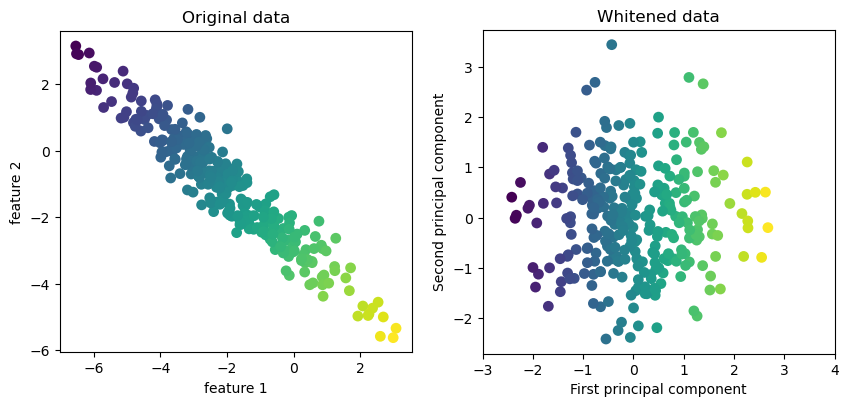

In [10]:
mglearn.plots.plot_pca_whitening() 
plt.show() 

X_train_pca.shape: (1547, 100)
Test set accuracy: 0.30
pca.components_.shape: (100, 5655)


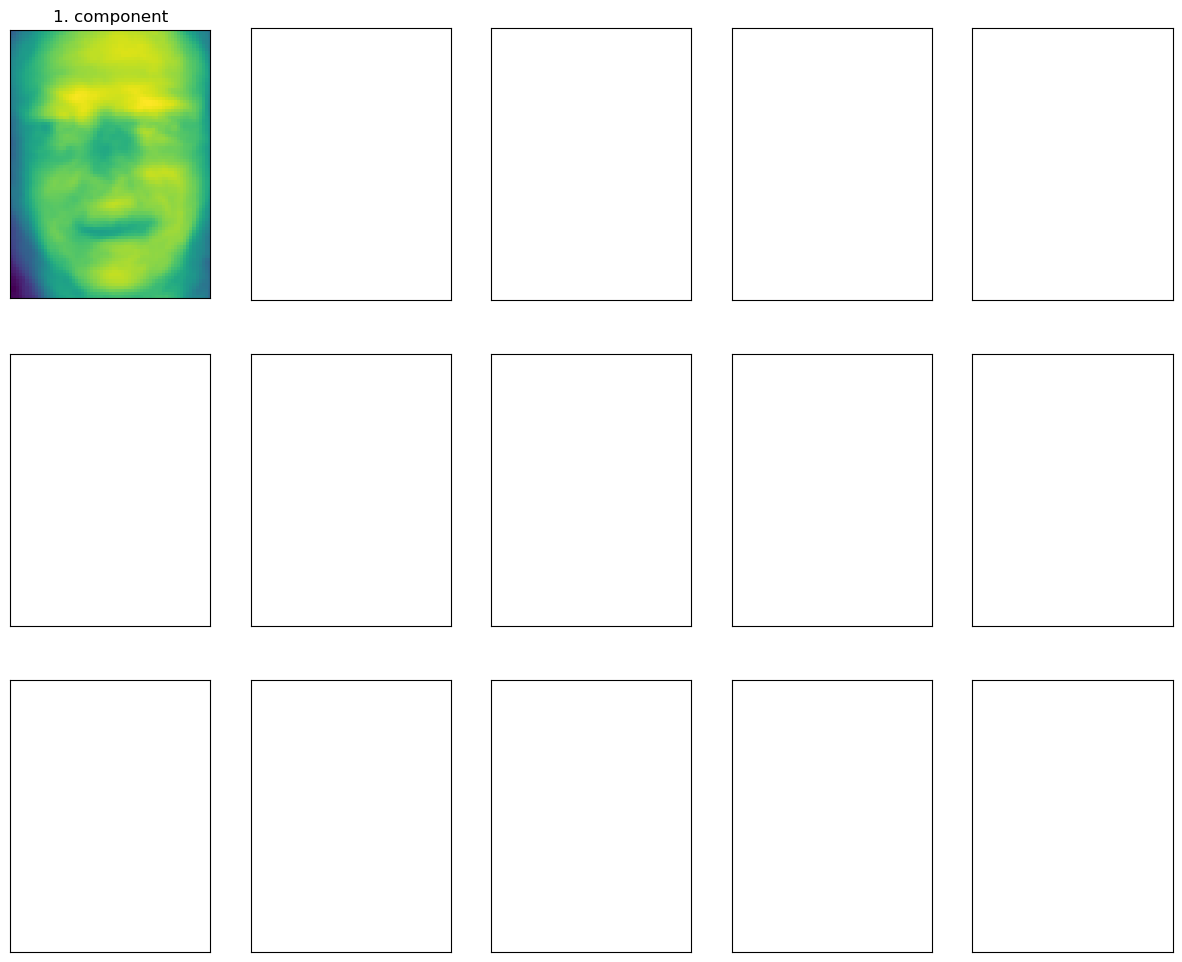

In [11]:
pca = PCA(     
    n_components=100,     
    whiten=True,     
    random_state=0 
).fit(X_train) 
X_train_pca = pca.transform(X_train) 
X_test_pca = pca.transform(X_test)
print(     "X_train_pca.shape: {}".format( X_train_pca.shape ) ) # KNN with PCA 
knn = KNeighborsClassifier(     n_neighbors=1 ) 
knn.fit(     X_train_pca,     y_train ) 
print(     "Test set accuracy: {:.2f}".format(knn.score(  X_test_pca, y_test )) ) 
print( "pca.components_.shape: {}".format( pca.components_.shape )) 


fix, axes = plt.subplots( 3, 5, figsize=(15,12), subplot_kw={'xticks':(), 'yticks':()} )
for i, (component, ax) in enumerate( zip(pca.components_, axes.ravel())):
    ax.imshow( component.reshape(image_shape), cmap='viridis' ) 
    ax.set_title( 
        "{}. component".format(i+1)     ) 
    plt.show()  

In [12]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(     X_train_pca )
X_test_scaled = scaler.transform(     X_test_pca ) 

In [ ]:
model = Sequential([      Input(         shape=(100,)     ),      Dense(         300,         activation='relu'     ),      Dense(         100,         activation='relu'     ),      Dense(         len(np.unique(y_train)),         activation='softmax'     )  ]) 

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(
    optimizer=Adam(),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [16]:
history = model.fit( X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False, verbose=1) 

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0233 - loss: 4.1254
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0175 - loss: 4.0892
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0356 - loss: 4.0661
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0381 - loss: 4.0463
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0517 - loss: 4.0270
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0575 - loss: 4.0033
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0743 - loss: 3.9766
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1086 - loss: 3.9415 
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1338 - loss: 3.8975 
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1526 - loss: 3.8415
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1629 - loss: 3.7709 
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1946 -

In [17]:
loss, accuracy = model.evaluate( X_test_scaled,y_test,verbose=1)
print("Test Loss:", loss) 
print("Test Accuracy:", accuracy) 

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2849 - loss: 2.9654  
Test Loss: 2.9653584957122803
Test Accuracy: 0.2848837077617645
